In [17]:
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, TensorDataset, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [18]:
df = pd.read_csv('/content/drive/MyDrive/house_price_regression_dataset.csv')
df.head()

X = torch.tensor(df.iloc[:, :-1].values, dtype=torch.float32)
y = torch.tensor(df.iloc[:, -1].values, dtype=torch.long)

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

for xb, yb in loader:
    print(xb.shape, yb.shape)

torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
torch.Size([32, 7]) torch.Size([32])
t

In [19]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [20]:
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


In [21]:
df['Year_Built'].unique()

array([1981, 2016, 1977, 1993, 1990, 2012, 1972, 1997, 2006, 1982, 1973,
       1988, 1983, 2005, 1986, 1956, 2017, 2014, 1996, 1969, 1968, 1978,
       2009, 1967, 1984, 1992, 1960, 1998, 1987, 2013, 2018, 1957, 1980,
       1953, 1999, 1979, 2008, 1994, 1975, 1976, 1995, 2000, 1955, 1964,
       1991, 2022, 1966, 1971, 1962, 2002, 1952, 1970, 1950, 1954, 1985,
       2003, 1961, 2019, 2001, 2004, 2011, 2021, 2010, 1959, 2015, 2020,
       1974, 1958, 1963, 1965, 1989, 2007, 1951])

In [22]:
X = df.drop('House_Price', axis=1)
y = df['House_Price']

In [23]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.3, random_state=42)

print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("X_val shape: ", X_val.shape)

X_train shape:  (700, 7)
X_test shape:  (90, 7)
X_val shape:  (210, 7)


In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

In [25]:
print("Trained processed shape: ", X_train_scaled.shape)
print("Test processed shape: ", X_test_scaled.shape)

Trained processed shape:  (700, 7)
Test processed shape:  (90, 7)


In [26]:
print(y_train.shape)
print(y_train.dtypes)

(700,)
float64


In [27]:
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))
y_val_scaled = y_scaler.transform(y_val.values.reshape(-1, 1))

In [28]:
input_dim = X_train_scaled.shape[1]
output_dim = 1

class NeuralNetwork(nn.Module):
  def __init__(self):
    super(NeuralNetwork, self).__init__()
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Linear(64, output_dim)
    )

  def forward(self, x):
    logits = self.linear_relu_stack(x)
    return logits


model = NeuralNetwork()
print(model)

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [29]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Next, we'll implement the training and validation loop. We'll train for a specified number of epochs, iterating through our training data and calculating the loss. We'll also validate the model's performance on a separate validation set.

In [30]:
def train_model(model, X_train, y_train, X_val, y_val, loss_fn, optimizer, epochs=100, batch_size=32):
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
  y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
  X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
  y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

  train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

  val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
  val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

  train_losses = []
  val_losses = []

  for epoch in range(epochs):
    model.train() # Set model to training mode
    current_train_loss = 0.0
    for batch_X, batch_y in train_loader:
      optimizer.zero_grad() # Clear gradients
      outputs = model(batch_X) # Forward pass
      loss = loss_fn(outputs, batch_y) # Calculate loss
      loss.backward() # Backward pass
      optimizer.step() # Update weights
      current_train_loss += loss.item() * batch_X.size(0)

    train_losses.append(current_train_loss / len(train_dataset))

    model.eval() # Set model to evaluation mode
    current_val_loss = 0.0
    with torch.no_grad(): # Disable gradient calculation for validation
      for batch_X, batch_y in val_loader:
        outputs = model(batch_X)
        loss = loss_fn(outputs, batch_y)
        current_val_loss += loss.item() * batch_X.size(0)

    val_losses.append(current_val_loss / len(val_dataset))

    if (epoch + 1) % 10 == 0:
      print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}')

  return train_losses, val_losses

# Call the train_model function
epochs = 100
train_hist, val_hist = train_model(model, X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled, loss_fn, optimizer, epochs=epochs)

Epoch 10/100, Train Loss: 0.0073, Val Loss: 0.0072
Epoch 20/100, Train Loss: 0.0039, Val Loss: 0.0046
Epoch 30/100, Train Loss: 0.0032, Val Loss: 0.0041
Epoch 40/100, Train Loss: 0.0028, Val Loss: 0.0037
Epoch 50/100, Train Loss: 0.0026, Val Loss: 0.0035
Epoch 60/100, Train Loss: 0.0024, Val Loss: 0.0033
Epoch 70/100, Train Loss: 0.0022, Val Loss: 0.0032
Epoch 80/100, Train Loss: 0.0020, Val Loss: 0.0030
Epoch 90/100, Train Loss: 0.0019, Val Loss: 0.0029
Epoch 100/100, Train Loss: 0.0017, Val Loss: 0.0028


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
model.eval() # Set model to evaluation mode
with torch.no_grad():
  y_pred_test_scaled = model(X_test_tensor).numpy()

# Inverse transform the scaled predictions and actual values
y_pred_test = y_scaler.inverse_transform(y_pred_test_scaled)
y_test_actual = y_scaler.inverse_transform(y_test_scaled)

# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_test)
mse = mean_squared_error(y_test_actual, y_pred_test)
r2 = r2_score(y_test_actual, y_pred_test)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")

Mean Absolute Error (MAE): 10,944.45
Mean Squared Error (MSE): 225,042,024.99
R-squared (R2 Score): 0.9969


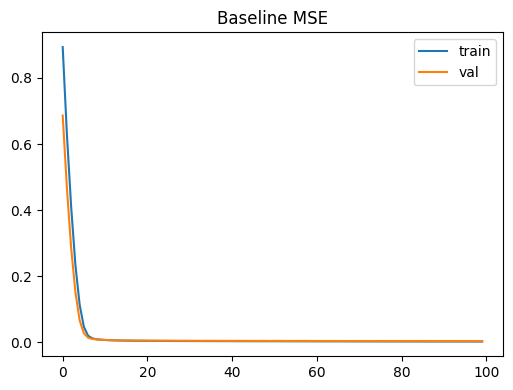

In [32]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.title('Baseline MSE')
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
import numpy as np
x_raw = np.array([[4272, 3, 3, 2016, 4.753014, 1, 6]], dtype=np.float32)

# 2) Scale and Predict
x_scaled = scaler.transform(x_raw)
y_pred_scaled = model(torch.tensor(x_scaled, dtype=torch.float32)).detach().numpy()
y_pred = y_scaler.inverse_transform(y_pred_scaled)

# 3) Get actual value from the dataframe (assuming this was row index 1)
actual_val = df.iloc[1, -1] # or just write the value
predicted_val = y_pred.item()

# 4) Calculate metrics
difference = abs(actual_val - predicted_val)
percent_error = (difference / actual_val) * 100

print(f"Actual: {actual_val:,.2f}") # Added commas for readability
print(f"Predicted: {predicted_val:,.2f}")
print(f"Difference: {difference:,.2f} ({percent_error:.2f}%)")

Actual: 985,260.85
Predicted: 971,912.31
Difference: 13,348.54 (1.35%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
